# Week 2 - Confidence Intervals & Bootstrap

Calculates traditional (z/t-based) and bootstrap confidence intervals for every numeric column, and compares the two methods.

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
from scipy import stats
from src.data_loader import DataLoader
import matplotlib.pyplot as plt

np.random.seed(42)

# Load cleaned data
loader = DataLoader()
df = pd.read_csv(loader.processed_dir / "cleaned_data.csv")

# Re-apply categorical dtype (dtype doesn't survive a plain CSV round-trip)
for col in df.columns:
    if df[col].nunique() < 10:
        df[col] = df[col].astype('category')

print("=" * 60)
print("CONFIDENCE INTERVALS & BOOTSTRAP")
print("=" * 60)

In [2]:
# ==================== 1. CONFIDENCE INTERVALS ====================
def calculate_confidence_interval(data, confidence=0.95):
    """Calculate confidence interval for mean."""
    n = len(data)
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    se = std / np.sqrt(n)

    if n >= 30:
        z_score = stats.norm.ppf((1 + confidence) / 2)
        margin = z_score * se
        dist = 'z (normal)'
    else:
        t_score = stats.t.ppf((1 + confidence) / 2, df=n-1)
        margin = t_score * se
        dist = "t (Student's)"

    return {'n': n, 'mean': mean, 'std': std, 'se': se, 'margin': margin,
            'lower': mean - margin, 'upper': mean + margin, 'distribution': dist}

# Calculate CIs for all numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
ci_results = {}
for col in numeric_cols:
    data = df[col].dropna()
    if len(data) > 0:
        ci_results[col] = calculate_confidence_interval(data)
        print(f"\n{col}")
        print(f"  n = {ci_results[col]['n']}")
        print(f"  Mean = {ci_results[col]['mean']:.3f}")
        print(f"  95% CI: ({ci_results[col]['lower']:.3f}, {ci_results[col]['upper']:.3f})")
        print(f"  Using {ci_results[col]['distribution']} distribution")


age
  n = 302
  Mean = 54.421
  95% CI: (53.400, 55.441)
  Using z (normal) distribution

trestbps
  n = 302
  Mean = 131.258
  95% CI: (129.385, 133.131)
  Using z (normal) distribution

chol
  n = 302
  Mean = 245.377
  95% CI: (240.021, 250.733)
  Using z (normal) distribution

thalach
  n = 302
  Mean = 149.613
  95% CI: (147.045, 152.181)
  Using z (normal) distribution

oldpeak
  n = 302
  Mean = 1.028
  95% CI: (0.903, 1.153)
  Using z (normal) distribution

hr_reserve
  n = 302
  Mean = 15.966
  95% CI: (13.608, 18.325)
  Using z (normal) distribution

chol_age_ratio
  n = 302
  Mean = 4.613
  95% CI: (4.492, 4.734)
  Using z (normal) distribution

In [3]:
# ==================== 2. BOOTSTRAP ====================
def bootstrap_ci(data, statistic=np.mean, n_bootstrap=10000, confidence=0.95):
    """Calculate bootstrap confidence interval."""
    n = len(data)
    bootstrap_stats = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=n, replace=True)
        bootstrap_stats.append(statistic(sample))

    alpha = 1 - confidence
    lower = np.percentile(bootstrap_stats, alpha/2 * 100)
    upper = np.percentile(bootstrap_stats, (1 - alpha/2) * 100)

    return {'original': statistic(data), 'bootstrap_mean': np.mean(bootstrap_stats),
            'bootstrap_std': np.std(bootstrap_stats), 'lower': lower, 'upper': upper,
            'confidence': confidence}

# Bootstrap for each numeric column
bootstrap_results = {}
for col in numeric_cols:
    data = df[col].dropna()
    if len(data) > 0:
        bootstrap_results[col] = bootstrap_ci(data)
        print(f"\n{col} (Bootstrap)")
        print(f"  Original mean: {bootstrap_results[col]['original']:.3f}")
        print(f"  Bootstrap mean: {bootstrap_results[col]['bootstrap_mean']:.3f}")
        print(f"  95% Bootstrap CI: ({bootstrap_results[col]['lower']:.3f}, {bootstrap_results[col]['upper']:.3f})")


age (Bootstrap)
  Original mean: 54.421
  Bootstrap mean: 54.427
  95% Bootstrap CI: (53.414, 55.464)

trestbps (Bootstrap)
  Original mean: 131.258
  Bootstrap mean: 131.252
  95% Bootstrap CI: (129.411, 133.123)

chol (Bootstrap)
  Original mean: 245.377
  Bootstrap mean: 245.340
  95% Bootstrap CI: (240.040, 250.692)

thalach (Bootstrap)
  Original mean: 149.613
  Bootstrap mean: 149.625
  95% Bootstrap CI: (147.017, 152.153)

oldpeak (Bootstrap)
  Original mean: 1.028
  Bootstrap mean: 1.028
  95% Bootstrap CI: (0.904, 1.155)

hr_reserve (Bootstrap)
  Original mean: 15.966
  Bootstrap mean: 15.964
  95% Bootstrap CI: (13.619, 18.301)

chol_age_ratio (Bootstrap)
  Original mean: 4.613
  Bootstrap mean: 4.614
  95% Bootstrap CI: (4.494, 4.735)

In [4]:
# ==================== 3. COMPARE CI METHODS ====================
print("\n" + "=" * 60)
print("COMPARISON: Traditional CI vs Bootstrap CI")
print("=" * 60)

comparison_data = []
for col in numeric_cols:
    if col in ci_results and col in bootstrap_results:
        comparison_data.append({
            'column': col,
            'mean': ci_results[col]['mean'],
            'ci_lower': ci_results[col]['lower'],
            'ci_upper': ci_results[col]['upper'],
            'bootstrap_lower': bootstrap_results[col]['lower'],
            'bootstrap_upper': bootstrap_results[col]['upper'],
            'ci_width': ci_results[col]['upper'] - ci_results[col]['lower'],
            'bootstrap_width': bootstrap_results[col]['upper'] - bootstrap_results[col]['lower']
        })

comparison_df = pd.DataFrame(comparison_data)
comparison_df.to_csv('../reports/ci_comparison.csv', index=False)
print(comparison_df.to_string())
print("\nConfidence interval results saved to 'reports/ci_comparison.csv'")


COMPARISON: Traditional CI vs Bootstrap CI
           column        mean    ci_lower    ci_upper  bootstrap_lower  bootstrap_upper   ci_width  bootstrap_width
0             age   54.420530   53.400070   55.440989        53.413907        55.463659   2.040919         2.049752
1        trestbps  131.258278  129.385486  133.131070       129.410596       133.122517   3.745584         3.711921
2            chol  245.377070  240.021367  250.732772       240.040242       250.692177  10.711405        10.651935
3         thalach  149.612997  147.045375  152.180618       147.017363       152.152742   5.135243         5.135379
4         oldpeak    1.027815    0.902581    1.153049         0.904305         1.154967   0.250468         0.250662
5      hr_reserve   15.966474   13.607595   18.325352        13.619174        18.300973   4.717756         4.681798
6  chol_age_ratio    4.612755    4.491731    4.733780         4.493896         4.734712   0.242049         0.240815

Confidence interval results

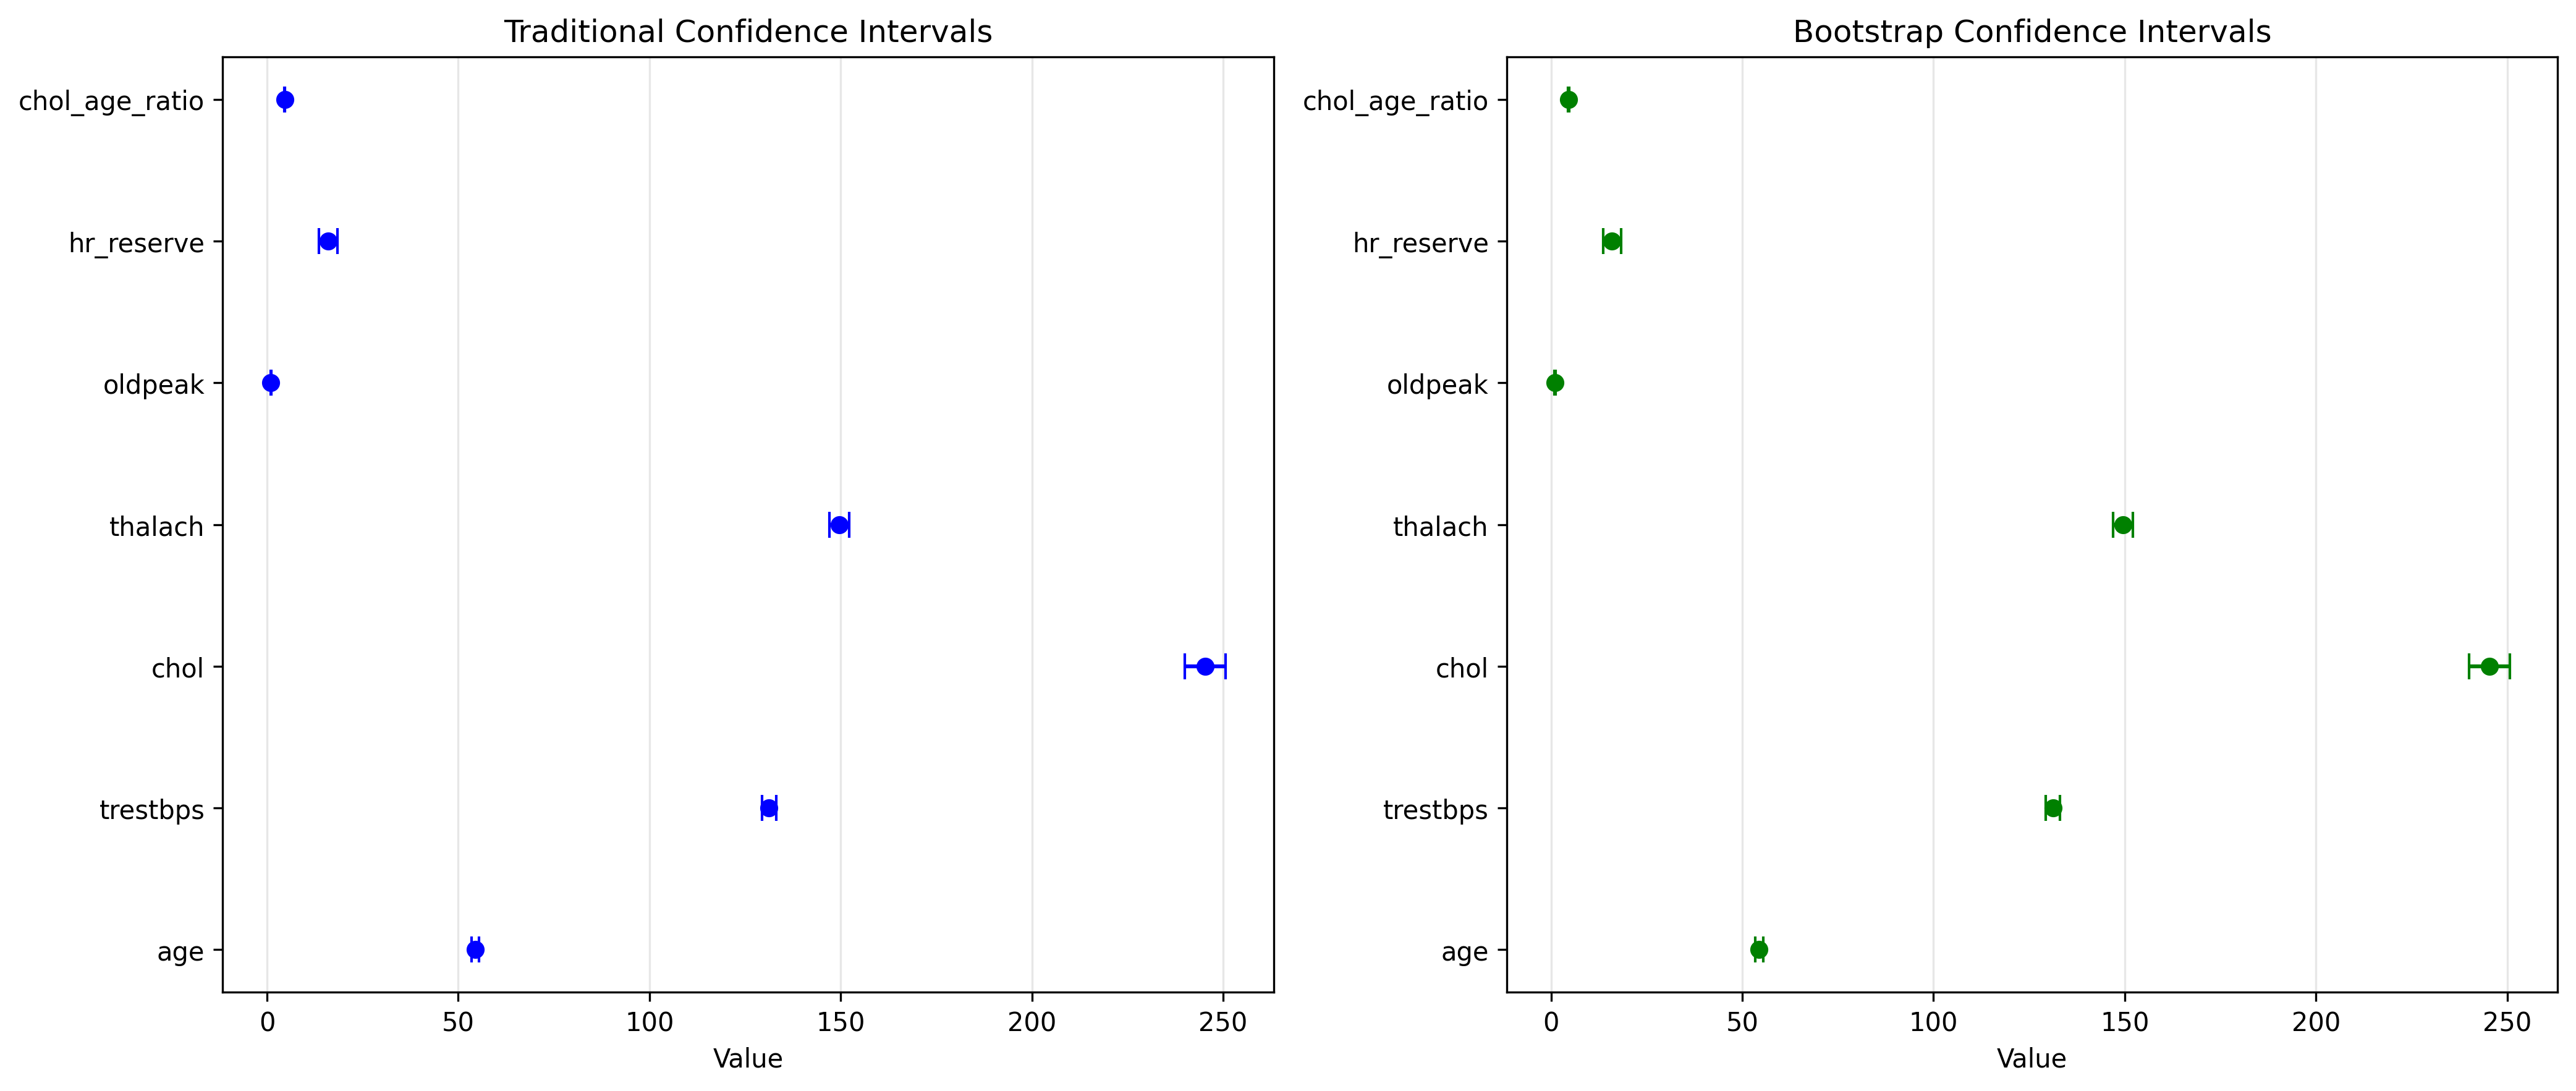

Confidence interval visualizations saved

In [5]:
# ================= 4. VISUALIZE CONFIDENCE INTERVALS =================
def plot_confidence_intervals(ci_results, bootstrap_results):
    """Plot confidence intervals for all numeric columns."""
    cols = list(ci_results.keys())
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    for i, col in enumerate(cols):
        ci = ci_results[col]
        ax1.errorbar(ci['mean'], i, xerr=ci['margin'], fmt='o', capsize=5, color='blue')
    ax1.set_yticks(range(len(cols)))
    ax1.set_yticklabels(cols)
    ax1.set_xlabel('Value')
    ax1.set_title('Traditional Confidence Intervals')
    ax1.grid(axis='x', alpha=0.3)

    for i, col in enumerate(cols):
        if col in bootstrap_results:
            boot = bootstrap_results[col]
            ax2.errorbar(boot['original'], i,
                         xerr=[[boot['original'] - boot['lower']], [boot['upper'] - boot['original']]],
                         fmt='o', capsize=5, color='green')
    ax2.set_yticks(range(len(cols)))
    ax2.set_yticklabels(cols)
    ax2.set_xlabel('Value')
    ax2.set_title('Bootstrap Confidence Intervals')
    ax2.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig('../reports/figures/confidence_intervals_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot CIs
if ci_results and bootstrap_results:
    plot_confidence_intervals(ci_results, bootstrap_results)
    print("\nConfidence interval visualizations saved")